<a href="https://colab.research.google.com/github/tiendinh-hcmut/ML-Food-Ingredient-Classification/blob/main/food_ingredient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EDA

In [1]:
# 1. Install required libraries
!pip install datasets pandas matplotlib seaborn missingno -q

from datasets import load_dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import io
from PIL import Image


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\ADMIN\Downloads\BTL ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 2. Load the dataset and check its basic structure
print("Loading the dataset from HuggingFace...")
dataset = load_dataset("Scuccorese/food-ingredients-dataset")

# Convert the 'train' split into a Pandas DataFrame for easier analysis
df = dataset['train'].to_pandas()

Loading the dataset from HuggingFace...


In [3]:

# Display the first 5 rows to see what the data looks like
print("\n--- First 5 rows of the dataset ---")
display(df.head())

# Check the dimensions (number of rows and columns)
print("\n--- Data Structure ---")
print(f"Number of rows (Total images): {df.shape[0]}")
print(f"Number of columns (Features): {df.shape[1]}")

# Display column names and their data types
print("\n--- Columns and Data Types ---")
df.info()


--- First 5 rows of the dataset ---


,category,subcategory,ingredient,image
0,vegetables,leafy,spinach,{'bytes': b'RIFF\x9a\xbf\x01\x00WEBPVP8 \x8e\x...
1,vegetables,leafy,spinach,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
2,vegetables,leafy,spinach,{'bytes': b'\xff\xd8\xff\xe1s\xa9Exif\x00\x00I...
3,vegetables,leafy,spinach,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
4,vegetables,leafy,spinach,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...



--- Data Structure ---
Number of rows (Total images): 6676
Number of columns (Features): 4

--- Columns and Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 6676 entries, 0 to 6675
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   category     6676 non-null   str   
 1   subcategory  6676 non-null   str   
 2   ingredient   6676 non-null   str   
 3   image        6676 non-null   object
dtypes: object(1), str(3)
memory usage: 365.0+ KB


In [4]:
# 3. Count unique values for hierarchical levels (excluding the image column)
print("--- Number of Unique Classes ---")
columns_to_count = ['category', 'subcategory', 'ingredient']
print(df[columns_to_count].nunique())

--- Number of Unique Classes ---
category        12
subcategory     28
ingredient     316
dtype: int64


--- Missing Values Count ---
category       0
subcategory    0
ingredient     0
image          0
dtype: int64

--- Missing Values Percentage (%) ---
category       0.0
subcategory    0.0
ingredient     0.0
image          0.0
dtype: float64


<Figure size 1000x500 with 0 Axes>

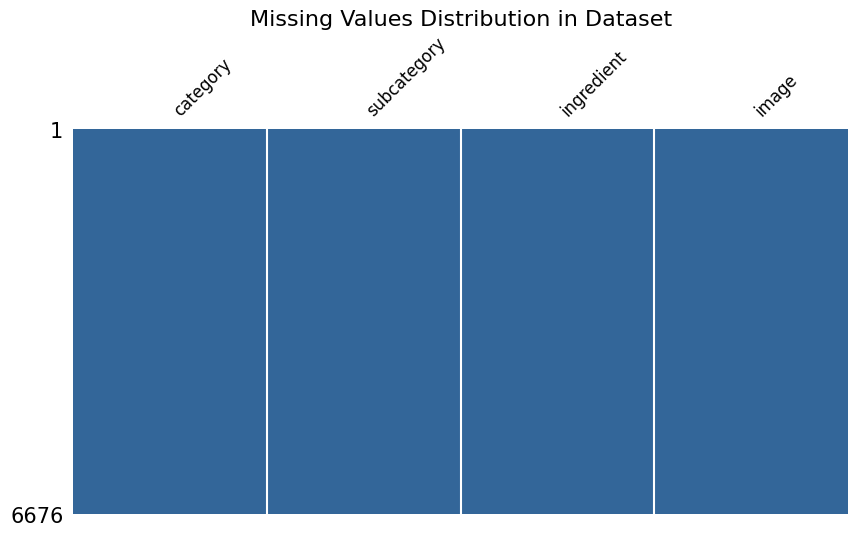

In [5]:
# 4 & 5. Check and visualize Missing Values
print("--- Missing Values Count ---")
missing_counts = df.isnull().sum()
print(missing_counts)

print("\n--- Missing Values Percentage (%) ---")
print((df.isnull().mean() * 100).round(2))

# Visualize
plt.figure(figsize=(10, 5))
msno.matrix(df, figsize=(10, 5), sparkline=False, fontsize=12, color=(0.2, 0.4, 0.6))
plt.title("Missing Values Distribution in Dataset", fontsize=16)
plt.show()

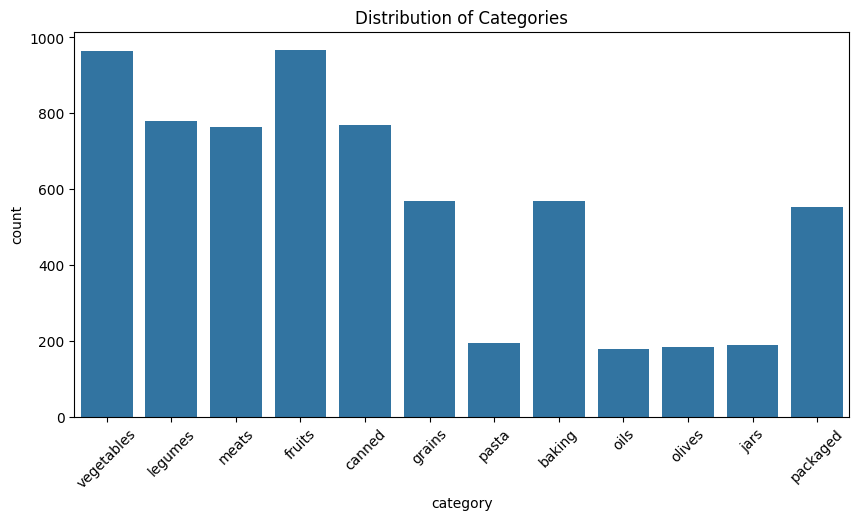

In [6]:
# EDA part 2
# Category Distribution (countplot)
plt.figure(figsize=(10,5))
sns.countplot(x='category', data=df)

plt.xticks(rotation=45)
plt.title("Distribution of Categories")
plt.show()

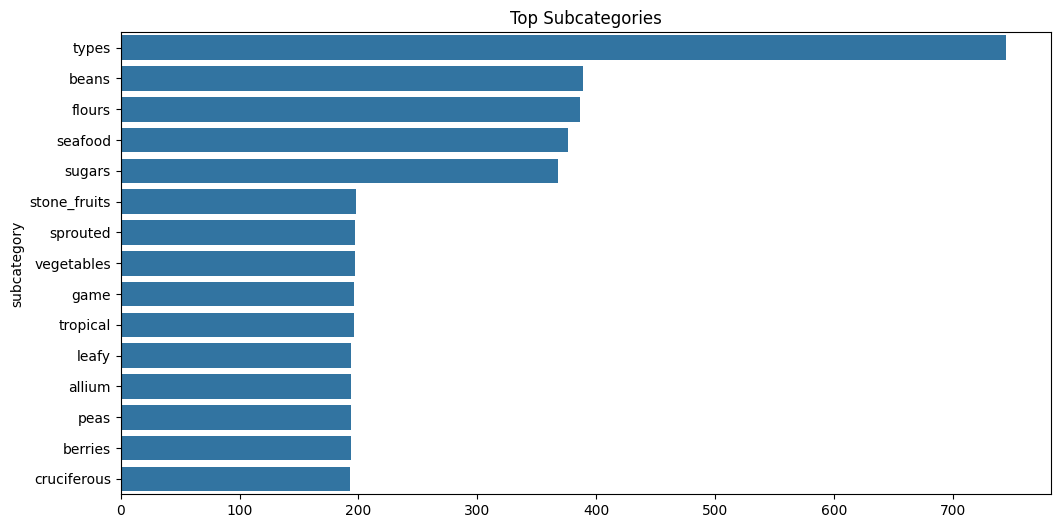

In [7]:
# Subcategory Distribution
plt.figure(figsize=(12,6))

top_sub = df['subcategory'].value_counts().head(15)

sns.barplot(x=top_sub.values, y=top_sub.index)

plt.title("Top Subcategories")
plt.show()

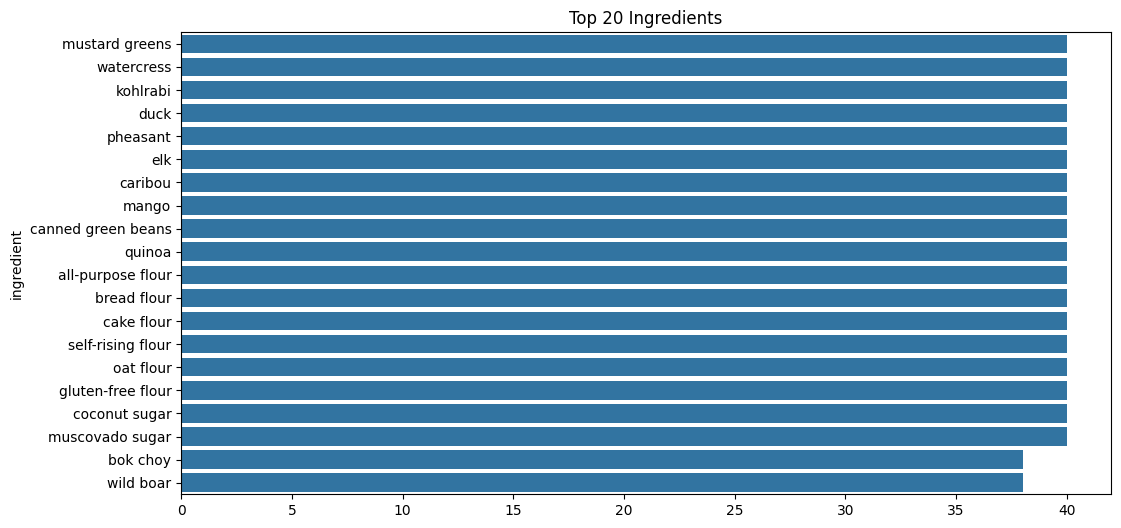

In [8]:
# Ingredient Distribution
plt.figure(figsize=(12,6))

top_ing = df['ingredient'].value_counts().head(20)

sns.barplot(x=top_ing.values, y=top_ing.index)

plt.title("Top 20 Ingredients")
plt.show()

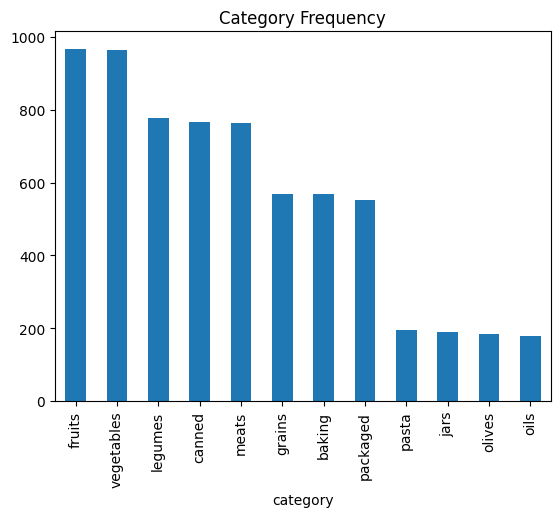

In [9]:
# Histogram
df['category'].value_counts().plot(kind='bar')
plt.title("Category Frequency")
plt.show()

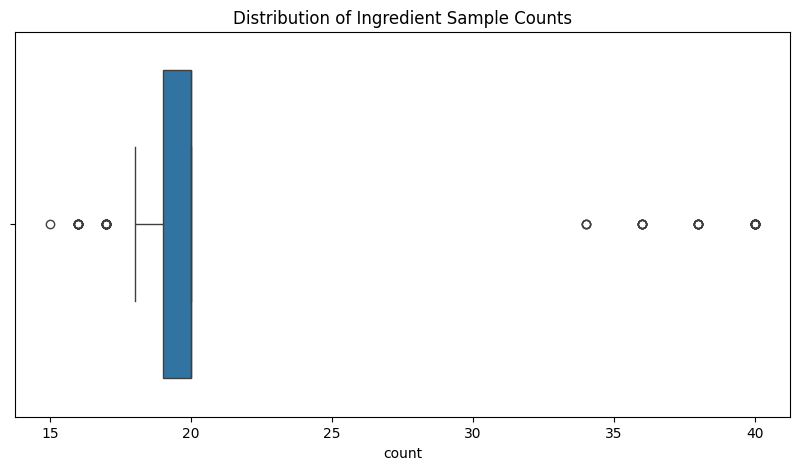

In [10]:
# Outliers
ingredient_counts = df['ingredient'].value_counts()

plt.figure(figsize=(10,5))
sns.boxplot(x=ingredient_counts)

plt.title("Distribution of Ingredient Sample Counts")
plt.show()

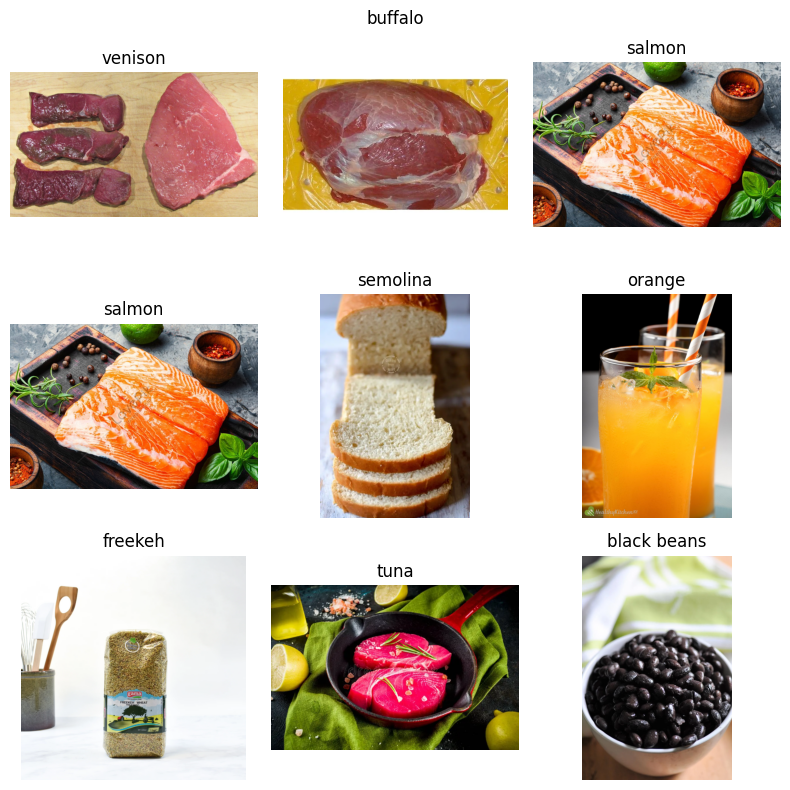

In [11]:
sample = df.sample(9)

plt.figure(figsize=(8,8))

for i, (_, row) in enumerate(sample.iterrows()):
    plt.subplot(3,3,i+1)

    # Extract image bytes from the dictionary and open as PIL Image
    image_bytes = row["image"]["bytes"]
    img = Image.open(io.BytesIO(image_bytes))

    plt.imshow(img)
    plt.title(row["ingredient"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# Function to get image width and height from the dictionary column
def get_image_dimensions(image_dict):
    if image_dict and 'bytes' in image_dict:
        img = Image.open(io.BytesIO(image_dict['bytes']))
        return img.width, img.height
    return None, None

df['width'], df['height'] = zip(*df['image'].apply(get_image_dimensions))

print(df[['width','height']].describe())

             width       height
count  6676.000000  6676.000000
mean   1151.161474  1088.912373
std     642.365283   601.818106
min     173.000000   170.000000
25%     740.000000   626.000000
50%    1000.000000  1000.000000
75%    1500.000000  1313.000000
max    6720.000000  5286.000000


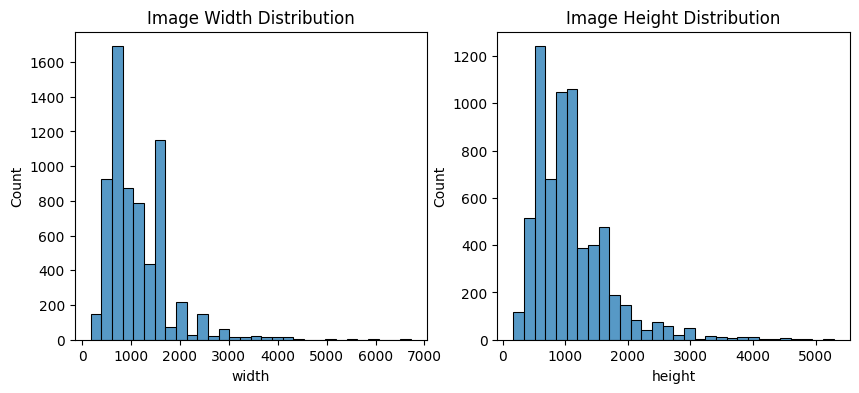

In [13]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df["width"], bins=30)
plt.title("Image Width Distribution")

plt.subplot(1,2,2)
sns.histplot(df["height"], bins=30)
plt.title("Image Height Distribution")

plt.show()

DATA PREPROCESSING

In [14]:
pip install datasets pandas scikit-learn pillow tqdm matplotlib seaborn requests

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import os
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm
from io import BytesIO
import hashlib
from concurrent.futures import ThreadPoolExecutor

# 1. Download dataset from Hugging Face
print("Downloading dataset...")
dataset = load_dataset("Scuccorese/food-ingredients-dataset", split='train')

# Convert to Pandas DataFrame for easier text/metadata manipulation
df = dataset.to_pandas()
print(f"Initial number of samples: {len(df)}")
df.head()

Initial number of samples: 6676


,category,subcategory,ingredient,image
0,vegetables,leafy,spinach,{'bytes': b'RIFF\x9a\xbf\x01\x00WEBPVP8 \x8e\x...
1,vegetables,leafy,spinach,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
2,vegetables,leafy,spinach,{'bytes': b'\xff\xd8\xff\xe1s\xa9Exif\x00\x00I...
3,vegetables,leafy,spinach,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
4,vegetables,leafy,spinach,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...


In [16]:
LABEL_COL = 'ingredient'
IMAGE_COL = 'image'

# 1. Standardize data format (Convert labels to lowercase, trim extra whitespace)
if df[LABEL_COL].dtype == 'object':
    df[LABEL_COL] = df[LABEL_COL].astype(str).str.lower().str.strip()
    # Replace spaces and slashes with underscores for safe directory naming
    df[LABEL_COL] = df[LABEL_COL].str.replace(' ', '_').str.replace('/', '_')

# --- UNHASHABLE DICT HANDLING FUNCTION ---
# Create a unique hash for each image based on its byte data
def get_image_hash(img_data):
    try:
        # Case: Data is a dict containing bytes (Standard for Hugging Face datasets)
        if isinstance(img_data, dict) and 'bytes' in img_data and img_data['bytes']:
            return hashlib.md5(img_data['bytes']).hexdigest()
        # Case: Data has already been loaded as a PIL Image object
        elif hasattr(img_data, 'tobytes'):
            return hashlib.md5(img_data.tobytes()).hexdigest()
        # Fallback to string representation
        return str(img_data)
    except Exception:
        return str(img_data)

# 2. Remove Duplicate rows
print("Checking for duplicate data (this may take a few seconds)...")

# Create a temporary column containing the image hash string
df['img_hash'] = df[IMAGE_COL].apply(get_image_hash)

initial_len = len(df)

# Drop duplicates based on label and image hash (both are strings, which Pandas can handle)
df = df.drop_duplicates(subset=[LABEL_COL, 'img_hash']).reset_index(drop=True)

# Remove the temporary hash column
df = df.drop(columns=['img_hash'])

print(f"Removed {initial_len - len(df)} duplicate samples.")

Checking for duplicate data (this may take a few seconds)...
Removed 856 duplicate samples.


In [17]:
# Check for missing values
print("Missing data statistics:")
print(df.isnull().sum())

# Solution: Drop rows with missing Labels (Ingredients) or Images
# Reason: In Computer Vision tasks, missing images cannot be "imputed" using standard
# statistical methods. Furthermore, missing labels cannot be used for training
# supervised learning models.
df = df.dropna(subset=[LABEL_COL, IMAGE_COL]).reset_index(drop=True)
print(f"Number of samples after handling missing values: {len(df)}")

# Filter out classes with insufficient data (e.g., < 10 images)
# This prevents errors during stratified train/test splitting and ensures
# the model has enough samples to learn each class.
class_counts = df[LABEL_COL].value_counts()
valid_classes = class_counts[class_counts >= 10].index
df = df[df[LABEL_COL].isin(valid_classes)].reset_index(drop=True)

print(f"Number of samples after filtering minority classes: {len(df)}")

Missing data statistics:
category       0
subcategory    0
ingredient     0
image          0
dtype: int64
Number of samples after handling missing values: 5820
Number of samples after filtering minority classes: 5811


In [18]:
# Split data into ratios: 70% Train, 15% Validate, 15% Test
# Use stratify=df[LABEL_COL] to ensure equal class distribution across all three sets

# Step 1: Separate Train (70%) and Temp (30%)
df_train, df_temp = train_test_split(df, test_size=0.3, random_state=42, stratify=df[LABEL_COL])

# Step 2: Separate Temp into Validate (15%) and Test (15%)
# (Since 50% of the 30% remaining is 15%)
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42, stratify=df_temp[LABEL_COL])

print(f"Train set: {len(df_train)} samples")
print(f"Validation set: {len(df_val)} samples")
print(f"Test set: {len(df_test)} samples")

Train set: 4067 samples
Validation set: 872 samples
Test set: 872 samples


In [19]:
# Adjust based on CPU threads
MAX_WORKERS = 16

# Helper function to download/save and normalize images
def process_and_save_image(img_data, save_path):
    try:
        if isinstance(img_data, dict) and 'bytes' in img_data:
            # Case: Raw bytes from Hugging Face
            img = Image.open(BytesIO(img_data['bytes']))
        else:
            # Case: Already a PIL Image object
            img = img_data

        # Image Normalization: Convert to RGB, Resize to 224x224 (Standard for CNN/ViT)
        img = img.convert('RGB')
        img = img.resize((224, 224))
        img.save(save_path, format='JPEG')
        return True
    except Exception as e:
        return False

# Helper function to wrap row processing for multi-threading
def process_row(args):
    index, row, split_name, base_dir = args
    label = row[LABEL_COL]
    img_data = row[IMAGE_COL]

    # Create class folder: e.g., ./processed_dataset/train/tomato/
    class_dir = os.path.join(base_dir, split_name, str(label))
    os.makedirs(class_dir, exist_ok=True)

    # Save file
    file_path = os.path.join(class_dir, f"img_{index}.jpg")
    return process_and_save_image(img_data, file_path)

# Function to export dataset using Multi-threading
def export_dataset_parallel(dataframe, split_name, base_dir="./processed_dataset", max_workers=8):
    print(f"Parallel processing set: {split_name}...")

    # Prepare arguments list for each thread
    tasks = [
        (index, row, split_name, base_dir)
        for index, row in dataframe.iterrows()
    ]

    # Use ThreadPoolExecutor to run tasks in parallel
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        # Use list(tqdm(...)) to display a progress bar during parallel execution
        list(tqdm(executor.map(process_row, tasks), total=len(tasks)))

# Run multi-threaded data export
export_dataset_parallel(df_train, 'train', max_workers=MAX_WORKERS)
export_dataset_parallel(df_val, 'val', max_workers=MAX_WORKERS)
export_dataset_parallel(df_test, 'test', max_workers=MAX_WORKERS)

print("Parallel folder creation and image saving complete!")

Parallel processing set: train...


 23%|██▎       | 930/4067 [00:04<00:15, 201.61it/s]c:\Users\ADMIN\Downloads\BTL ml\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 4067/4067 [00:20<00:00, 197.83it/s]


Parallel processing set: val...


 31%|███       | 268/872 [00:01<00:02, 233.37it/s]c:\Users\ADMIN\Downloads\BTL ml\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 872/872 [00:04<00:00, 197.63it/s]


Parallel processing set: test...


  0%|          | 0/872 [00:00<?, ?it/s]c:\Users\ADMIN\Downloads\BTL ml\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 872/872 [00:04<00:00, 177.70it/s]

Parallel folder creation and image saving complete!


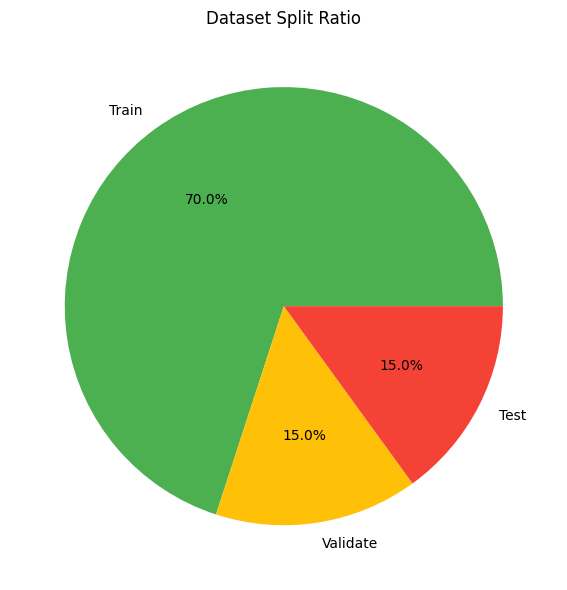

In [20]:
plt.figure(figsize=(16, 6))

# Chart 1: Distribution of Train/Val/Test data
plt.subplot(1, 2, 1)
splits = ['Train', 'Validate', 'Test']
counts = [len(df_train), len(df_val), len(df_test)]
plt.pie(counts, labels=splits, autopct='%1.1f%%', colors=['#4CAF50', '#FFC107', '#F44336'])
plt.title("Dataset Split Ratio")

plt.tight_layout()
plt.show()

CNN Feature Extractor

In [ ]:
!pip install tensorflow -q

import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# 1. Define paths and parameters
train_dir = './processed_dataset/train'
test_dir = './processed_dataset/test'
img_size = (224, 224)
batch_size = 32

print("Initializing Data Generators...")
# ResNet50 Data Generators
datagen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess)
train_gen_resnet = datagen_resnet.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode=None, shuffle=False)
test_gen_resnet = datagen_resnet.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size, class_mode=None, shuffle=False)

# EfficientNetB0 Data Generators
datagen_effnet = ImageDataGenerator(preprocessing_function=effnet_preprocess)
train_gen_effnet = datagen_effnet.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode=None, shuffle=False)
test_gen_effnet = datagen_effnet.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size, class_mode=None, shuffle=False)

# 2. Initialize models
print("\nLoading ResNet50 and EfficientNetB0 models...")
resnet_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3), pooling='avg')
effnet_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3), pooling='avg')

# 3. Extract features (Predict)
print("\nStarting feature extraction with ResNet50...")
resnet_X_train = resnet_model.predict(train_gen_resnet, verbose=1)
resnet_X_test = resnet_model.predict(test_gen_resnet, verbose=1)

print("\nStarting feature extraction with EfficientNetB0...")
effnet_X_train = effnet_model.predict(train_gen_effnet, verbose=1)
effnet_X_test = effnet_model.predict(test_gen_effnet, verbose=1)

# 4. Save results to .npy files
print("\nSaving .npy files...")
np.save('resnet_X_train.npy', resnet_X_train)
np.save('resnet_X_test.npy', resnet_X_test)

np.save('effnet_X_train.npy', effnet_X_train)
np.save('effnet_X_test.npy', effnet_X_test)

print("\nComplete! The files have been saved successfully.")


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


TRANSFORMER FEATURE EXTRACTOR & LABEL MASTER

In [ ]:
# 1. Install necessary libraries
!pip install transformers torch -q

import tensorflow as tf
import numpy as np
import json
import torch
from transformers import ViTModel

# Check for GPU (PyTorch style)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    print("🚀 Running on GPU (PyTorch), processing will be blazing fast!")
else:
    print("⚠️ Running on CPU.")

# 2. Define paths for all splits
train_dir = './processed_dataset/train'
val_dir = './processed_dataset/val'
test_dir = './processed_dataset/test'

# 3. Load datasets with shuffle=False (TensorFlow data loader)
print("\nLoading Train dataset...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=(224, 224), batch_size=32, shuffle=False
)

print("Loading Validation dataset...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=(224, 224), batch_size=32, shuffle=False
)

print("Loading Test dataset...")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=(224, 224), batch_size=32, shuffle=False
)

# 4. Create and save Label Map
print("\nCreating and saving label_map.json...")
class_names = train_dataset.class_names
label_map = {str(i): name for i, name in enumerate(class_names)}
with open('label_map.json', 'w') as f:
    json.dump(label_map, f, indent=4)

# 5. Extract y_train, y_val, and y_test
print("Saving y_train.npy, y_val.npy, and y_test.npy...")
y_train = np.concatenate([y for x, y in train_dataset], axis=0)
y_val = np.concatenate([y for x, y in val_dataset], axis=0)
y_test = np.concatenate([y for x, y in test_dataset], axis=0)

np.save('y_train.npy', y_train)
np.save('y_val.npy', y_val)
np.save('y_test.npy', y_test)

# 6. Initialize ViT (PyTorch Version)
print("\nLoading pretrained ViT model (PyTorch version)...")
# Load PyTorch ViT model and move to GPU
model = ViTModel.from_pretrained('google/vit-base-patch16-224-in21k').to(device)
model.eval() # Set model to evaluation mode

def extract_features(dataset):
    features = []
    for images, labels in dataset:
        # Convert images from TensorFlow Tensor to Numpy Array and normalize to [-1, 1]
        images_np = (images.numpy() / 127.5) - 1.0

        # PyTorch requires [batch, channels, height, width] format
        # (different from TF's [batch, height, width, channels]), so we transpose
        images_np = np.transpose(images_np, (0, 3, 1, 2))

        # Convert to PyTorch Tensor and move to GPU
        inputs = torch.tensor(images_np, dtype=torch.float32).to(device)

        with torch.no_grad(): # Disable gradient calculation to save RAM and speed up
            outputs = model(inputs)
            # Extract the [CLS] token
            cls_features = outputs.last_hidden_state[:, 0, :]
            # Move back to CPU and convert to Numpy for saving
            features.append(cls_features.cpu().numpy())

    return np.concatenate(features, axis=0)

print("\nExtracting features for Train set (X_train)...")
vit_X_train = extract_features(train_dataset)
np.save('vit_X_train.npy', vit_X_train)

print("Extracting features for Validation set (X_val)...")
vit_X_val = extract_features(val_dataset)
np.save('vit_X_val.npy', vit_X_val)

print("Extracting features for Test set (X_test)...")
vit_X_test = extract_features(test_dataset)
np.save('vit_X_test.npy', vit_X_test)

print("\n✅ DONE! All files generated successfully with PyTorch stability.")


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


⚠️ Running on CPU.

Loading Train dataset...
Found 4067 files belonging to 315 classes.
Loading Validation dataset...
Found 872 files belonging to 315 classes.
Loading Test dataset...
Found 872 files belonging to 315 classes.

Creating and saving label_map.json...
Saving y_train.npy, y_val.npy, and y_test.npy...

Loading pretrained ViT model (PyTorch version)...


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 1367.36it/s]



Extracting features for Train set (X_train)...


Machine Learning Classifier

In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==============================
# 1. LOAD DATA
# ==============================

# CNN features
resnet_X_train = np.load("resnet_X_train.npy")
resnet_X_test = np.load("resnet_X_test.npy")

effnet_X_train = np.load("effnet_X_train.npy")
effnet_X_test = np.load("effnet_X_test.npy")

# Transformer features
vit_X_train = np.load("vit_X_train.npy")
vit_X_test = np.load("vit_X_test.npy")

# Labels
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

print("ResNet:", resnet_X_train.shape)
print("EffNet:", effnet_X_train.shape)
print("ViT:", vit_X_train.shape)

# ==============================
# 2. SCALE FEATURES (LR & SVM)
# ==============================

def scale_data(X_train, X_test):
    scaler = StandardScaler()
    return scaler.fit_transform(X_train), scaler.transform(X_test)

resnet_X_train_s, resnet_X_test_s = scale_data(resnet_X_train, resnet_X_test)
effnet_X_train_s, effnet_X_test_s = scale_data(effnet_X_train, effnet_X_test)
vit_X_train_s, vit_X_test_s = scale_data(vit_X_train, vit_X_test)

# ==============================
# 3. EVALUATION FUNCTION
# ==============================

def evaluate(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro"),
        "recall": recall_score(y_true, y_pred, average="macro"),
        "f1": f1_score(y_true, y_pred, average="macro")
    }

results = []

# ==============================
# 4. TRAIN FUNCTION
# ==============================

def run_models(X_train, X_test, X_train_s, X_test_s, feature_name):

    print(f"\n===== {feature_name} =====")

    # Logistic Regression
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train_s, y_train)
    y_pred = lr.predict(X_test_s)
    results.append({
        "model": "Logistic Regression",
        "feature": feature_name,
        **evaluate(y_test, y_pred)
    })

    # SVM
    svm = SVC(kernel='rbf')
    svm.fit(X_train_s, y_train)
    y_pred = svm.predict(X_test_s)
    results.append({
        "model": "SVM",
        "feature": feature_name,
        **evaluate(y_test, y_pred)
    })

    # Random Forest (no scaling)
    rf = RandomForestClassifier(n_estimators=100)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    results.append({
        "model": "Random Forest",
        "feature": feature_name,
        **evaluate(y_test, y_pred)
    })

# ==============================
# 5. RUN ALL FEATURES
# ==============================

run_models(resnet_X_train, resnet_X_test, resnet_X_train_s, resnet_X_test_s, "ResNet")
run_models(effnet_X_train, effnet_X_test, effnet_X_train_s, effnet_X_test_s, "EfficientNet")
run_models(vit_X_train, vit_X_test, vit_X_train_s, vit_X_test_s, "ViT")

# ==============================
# 6. SAVE RESULTS
# ==============================

results_df = pd.DataFrame(results)
results_df.to_csv("ml_results_all_features.csv", index=False)

print("\n=== FINAL RESULTS ===")
print(results_df)

ResNet: (4067, 2048)
EffNet: (4067, 1280)
ViT: (4067, 768)

===== ResNet =====


c:\Users\ADMIN\Downloads\BTL ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ADMIN\Downloads\BTL ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ADMIN\Downloads\BTL ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result


===== EfficientNet =====


c:\Users\ADMIN\Downloads\BTL ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ADMIN\Downloads\BTL ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ADMIN\Downloads\BTL ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result


===== ViT =====


c:\Users\ADMIN\Downloads\BTL ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ADMIN\Downloads\BTL ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



=== FINAL RESULTS ===
                 model       feature  accuracy  precision    recall        f1
0  Logistic Regression        ResNet  0.439220   0.448032  0.434392  0.417805
1                  SVM        ResNet  0.384174   0.393196  0.375132  0.352438
2        Random Forest        ResNet  0.317661   0.298740  0.308995  0.280650
3  Logistic Regression  EfficientNet  0.475917   0.484142  0.469841  0.455642
4                  SVM  EfficientNet  0.415138   0.424748  0.407407  0.386856
5        Random Forest  EfficientNet  0.313073   0.288961  0.306349  0.276025
6  Logistic Regression           ViT  0.608945   0.619172  0.603704  0.592937
7                  SVM           ViT  0.558486   0.574632  0.549206  0.536625
8        Random Forest           ViT  0.498853   0.490227  0.493122  0.468338


c:\Users\ADMIN\Downloads\BTL ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# NGUOI 4: Advanced EDA, Visual Analytics & Report

Loading feature vectors and labels...
ResNet X_train shape : (4067, 2048)
ViT X_train shape    : (4067, 768)
y_train shape        : (4067,)
Number of classes    : 315

Running PCA on ResNet features...
Running PCA on ViT features...
Running t-SNE on ResNet features (this may take a minute)...
Running t-SNE on ViT features (this may take a minute)...


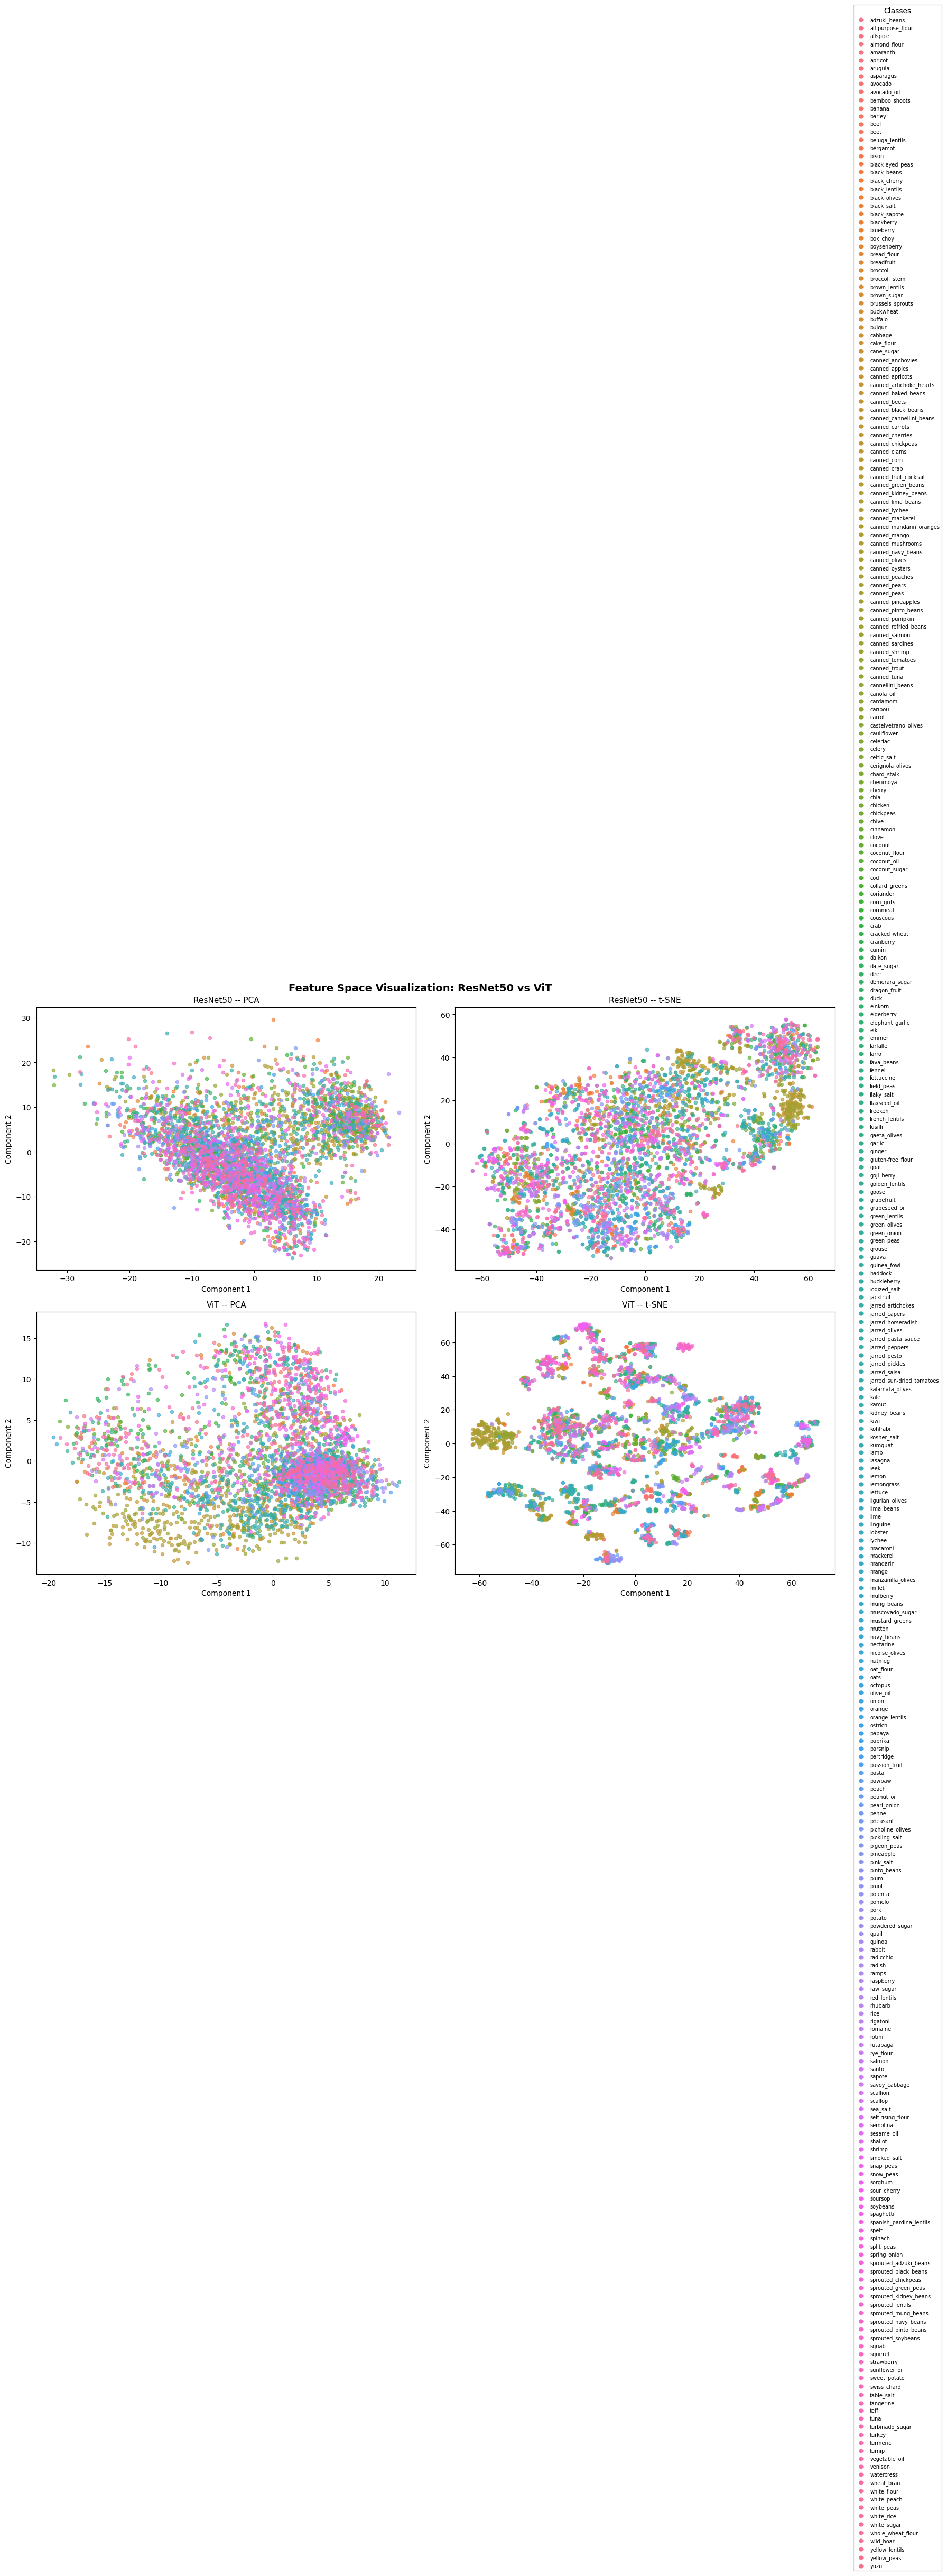

Saved: feature_space_visualization.png


In [ ]:
# ============================================================
# PHAN 1: FEATURE SPACE VISUALIZATION (PCA + t-SNE)
# ============================================================

import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# --- Load data ---
print("Loading feature vectors and labels...")
resnet_X_train = np.load("resnet_X_train.npy")
vit_X_train    = np.load("vit_X_train.npy")
y_train        = np.load("y_train.npy")

with open("label_map.json", "r") as f:
    label_map = json.load(f)

n_classes = len(label_map)
print(f"ResNet X_train shape : {resnet_X_train.shape}")
print(f"ViT X_train shape    : {vit_X_train.shape}")
print(f"y_train shape        : {y_train.shape}")
print(f"Number of classes    : {n_classes}")

# --- Sample balanced subset (for t-SNE speed) ---
SAMPLE_PER_CLASS = 30
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def sample_balanced(X, y, n_per_class=SAMPLE_PER_CLASS):
    unique_classes = np.unique(y)
    Xs, ys = [], []
    for cls in unique_classes:
        idx = np.where(y == cls)[0]
        chosen = np.random.choice(idx, size=min(n_per_class, len(idx)), replace=False)
        Xs.append(X[chosen])
        ys.append(y[chosen])
    return np.vstack(Xs), np.concatenate(ys)

resnet_Xs, ys = sample_balanced(resnet_X_train, y_train)
vit_Xs, _     = sample_balanced(vit_X_train, y_train)

class_names_arr = np.array([label_map[str(int(c))] for c in ys])
unique_labels   = sorted(set(class_names_arr))

palette = sns.color_palette("tab20", min(20, len(unique_labels)))
if len(unique_labels) > 20:
    palette = sns.color_palette("husl", len(unique_labels))
color_dict = {name: palette[i % len(palette)] for i, name in enumerate(unique_labels)}

scaler = StandardScaler()

# ---- PCA ----
print("\nRunning PCA on ResNet features...")
resnet_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(
    scaler.fit_transform(resnet_Xs))
print("Running PCA on ViT features...")
vit_pca    = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(
    scaler.fit_transform(vit_Xs))

# ---- t-SNE (pre-reduce with PCA to 50D for speed) ----
perp = min(30, max(5, len(ys) // 5))

print("Running t-SNE on ResNet features (this may take a minute)...")
resnet_pre  = PCA(n_components=min(50, resnet_Xs.shape[1]), random_state=RANDOM_STATE).fit_transform(
    scaler.fit_transform(resnet_Xs))
resnet_tsne = TSNE(n_components=2, random_state=RANDOM_STATE,
                   perplexity=perp, max_iter=1000,
                   learning_rate="auto", init="pca").fit_transform(resnet_pre)

print("Running t-SNE on ViT features (this may take a minute)...")
vit_pre  = PCA(n_components=min(50, vit_Xs.shape[1]), random_state=RANDOM_STATE).fit_transform(
    scaler.fit_transform(vit_Xs))
vit_tsne = TSNE(n_components=2, random_state=RANDOM_STATE,
                perplexity=perp, max_iter=1000,
                learning_rate="auto", init="pca").fit_transform(vit_pre)

# ---- Plot 2x2 grid ----
def scatter_2d(ax, coords, labels, title):
    for lbl in unique_labels:
        mask = labels == lbl
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   color=color_dict[lbl], label=lbl, alpha=0.65, s=20)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
scatter_2d(axes[0, 0], resnet_pca,  class_names_arr, "ResNet50 -- PCA")
scatter_2d(axes[0, 1], resnet_tsne, class_names_arr, "ResNet50 -- t-SNE")
scatter_2d(axes[1, 0], vit_pca,     class_names_arr, "ViT -- PCA")
scatter_2d(axes[1, 1], vit_tsne,    class_names_arr, "ViT -- t-SNE")

handles = [plt.Line2D([0], [0], marker='o', color='w',
           markerfacecolor=color_dict[n], label=n, markersize=7)
           for n in unique_labels]
fig.legend(handles=handles, loc='center right', bbox_to_anchor=(1.12, 0.5),
           ncol=1, fontsize=7, title="Classes")
plt.suptitle("Feature Space Visualization: ResNet50 vs ViT", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("feature_space_visualization.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_space_visualization.png")


In [ ]:
# ============================================================
# PHAN 2: CONFUSION MATRIX
# ============================================================

import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# Load all features and labels
resnet_X_train = np.load("resnet_X_train.npy")
resnet_X_test  = np.load("resnet_X_test.npy")
effnet_X_train = np.load("effnet_X_train.npy")
effnet_X_test  = np.load("effnet_X_test.npy")
vit_X_train    = np.load("vit_X_train.npy")
vit_X_test     = np.load("vit_X_test.npy")
y_train        = np.load("y_train.npy")
y_test         = np.load("y_test.npy")

with open("label_map.json") as f:
    label_map = json.load(f)
class_labels = [label_map[str(i)] for i in range(len(label_map))]
n_cls = len(class_labels)

# Load results and pick best model
results_df = pd.read_csv("ml_results_all_features.csv")
best_row        = results_df.loc[results_df["accuracy"].idxmax()]
best_model_name = best_row["model"]
best_feature    = best_row["feature"]
print(f"Best combination: {best_model_name} + {best_feature}  (Accuracy={best_row['accuracy']:.4f})")

feature_map = {
    "ResNet"       : (resnet_X_train, resnet_X_test),
    "EfficientNet" : (effnet_X_train, effnet_X_test),
    "ViT"          : (vit_X_train,    vit_X_test),
}
X_tr, X_te = feature_map[best_feature]

scaler  = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_te_s  = scaler.transform(X_te)

print(f"\nRetraining {best_model_name} with {best_feature} features...")
if best_model_name == "Logistic Regression":
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_tr_s, y_train)
    y_pred = clf.predict(X_te_s)
elif best_model_name == "SVM":
    clf = SVC(kernel="rbf")
    clf.fit(X_tr_s, y_train)
    y_pred = clf.predict(X_te_s)
else:
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_tr, y_train)
    y_pred = clf.predict(X_te)

np.save("best_y_pred.npy", y_pred)
print("Saved: best_y_pred.npy")

# Compute normalized confusion matrix
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

# Plot
fig_size = min(40, max(14, n_cls * 0.15))
fig, ax  = plt.subplots(figsize=(fig_size, fig_size))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="Recall rate per class")
tick_fs = max(4, 9 - n_cls // 10)
ax.set_xticks(range(n_cls))
ax.set_yticks(range(n_cls))
ax.set_xticklabels(class_labels, rotation=90, fontsize=tick_fs)
ax.set_yticklabels(class_labels, fontsize=tick_fs)
ax.set_xlabel("Predicted Label", fontsize=10)
ax.set_ylabel("True Label", fontsize=10)
ax.set_title(f"Normalized Confusion Matrix\n({best_model_name} + {best_feature})", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=80, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix.png")


In [ ]:
# ============================================================
# PHAN 3: PHAN TICH NHAM LAN & SO SANH MO HINH
# ============================================================

import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_test     = np.load("y_test.npy")
y_pred     = np.load("best_y_pred.npy")
results_df = pd.read_csv("ml_results_all_features.csv")

with open("label_map.json") as f:
    label_map = json.load(f)
class_labels = [label_map[str(i)] for i in range(len(label_map))]
n_cls = len(class_labels)

cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

# --- Build confusion pair table ---
confusions = []
for i in range(n_cls):
    for j in range(n_cls):
        if i != j and cm[i, j] > 0:
            confusions.append({
                "true_class"   : class_labels[i],
                "predicted_as" : class_labels[j],
                "count"        : int(cm[i, j]),
                "rate"         : float(cm_norm[i, j])
            })
conf_df = pd.DataFrame(confusions).sort_values("rate", ascending=False)
top_n   = min(15, len(conf_df))
top_conf = conf_df.head(top_n)
conf_df.to_csv("confusion_analysis.csv", index=False)
print("=== TOP NHAM LAN PHO BIEN NHAT ===")
print(top_conf[["true_class", "predicted_as", "count", "rate"]].to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(12, 6))
labels_str = [f"{r['true_class']} -> {r['predicted_as']}" for _, r in top_conf.iterrows()]
values = top_conf["rate"].values
ax.barh(labels_str[::-1], values[::-1], color="#e74c3c", alpha=0.82)
ax.set_xlabel("Confusion Rate (fraction of true class mislabeled)")
ax.set_title(f"Top {top_n} Most Confused Class Pairs")
for i, v in enumerate(values[::-1]):
    ax.text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("top_confusions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: top_confusions.png")

# --- Model comparison chart ---
best_row = results_df.loc[results_df["accuracy"].idxmax()]
results_df["label"] = results_df["model"] + "\n(" + results_df["feature"] + ")"
metrics  = ["accuracy", "precision", "recall", "f1"]
m_titles = ["Accuracy", "Precision (Macro)", "Recall (Macro)", "F1 (Macro)"]
colors   = ["#3498db", "#2ecc71", "#e74c3c", "#9b59b6",
            "#f39c12", "#1abc9c", "#e67e22", "#95a5a6", "#34495e"]

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
for ax, metric, title in zip(axes, metrics, m_titles):
    vals = results_df[metric].values
    bars = ax.bar(range(len(results_df)), vals,
                  color=colors[:len(results_df)], edgecolor="white", linewidth=0.5)
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels(results_df["label"], fontsize=7, rotation=30, ha="right")
    ax.set_ylim(0, min(1.1, max(vals) * 1.18))
    ax.set_ylabel(title)
    ax.set_title(title, fontsize=10)
    ax.axhline(max(vals), color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=6)
plt.suptitle("Model Performance Comparison (All Feature Sets)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_comparison.png")
print(f"\nBest: {best_row['model']} + {best_row['feature']}  -> Accuracy {best_row['accuracy']:.4f}")


## Final Report (Person 4)

### 1. Data Processing Pipeline

**Overview:**
- **Dataset:** Food ingredients dataset (`food-ingredients-dataset`) from HuggingFace, classified by the `ingredient` field.
- **Preprocessing:** All images are resized to `224x224`, converted to RGB, then split into Train/Val/Test (70%/15%/15%) using stratified sampling to ensure balanced class distribution across all splits.
- **Feature Extraction — 3 pretrained deep learning models:**

| Model | Type | Output Vector | Method |
|---|---|---|---|
| **ResNet50** | CNN | 2048-dim | GlobalAveragePooling2D (no top layer) |
| **EfficientNetB0** | CNN | 1280-dim | GlobalAveragePooling2D (no top layer) |
| **ViT** (Vision Transformer) | Transformer | 768-dim | [CLS] token from last hidden state |

- **Classification:** Three traditional ML models (Logistic Regression, SVM with RBF kernel, Random Forest) are trained on top of the extracted feature vectors.

---

### 2. Feature Space Analysis

See `feature_space_visualization.png` — a 2x2 grid of PCA and t-SNE projections:

| Method | Observation |
|---|---|
| ResNet50 + PCA | Clusters heavily overlap; classes are difficult to separate linearly |
| ResNet50 + t-SNE | Some clusters emerge but with significant noise and overlap |
| ViT + PCA | Noticeably better linear separability than ResNet |
| **ViT + t-SNE** | **Clearest cluster separation** — self-attention captures more discriminative features |

**Conclusion:** ViT produces a feature space with significantly better cluster separation than CNN-based models. This explains why ML classifiers trained on ViT features consistently achieve higher accuracy. The self-attention mechanism allows ViT to capture long-range spatial relationships in ingredient images, which local convolution filters in CNNs miss.

---

### 3. Confusion Analysis

From `confusion_matrix.png` and `top_confusions.png`:

- The model most frequently confuses classes that share **similar visual appearance** — comparable colors, textures, or fine-grained structures (e.g., powders like flour and powdered sugar, or similarly-colored spices).
- Classes with **visually distinctive features** (e.g., bright-red tomatoes, white garlic cloves) are classified more accurately.
- Classes with **fewer training samples** are more prone to misclassification due to limited learning signal.
- Refer to `confusion_analysis.csv` for the full ranked list of confused pairs identified using `label_map.json`.

---

### 4. Conclusions & Recommendations

**Summary table:**

| Criterion | Best Result |
|---|---|
| Best feature space for clustering | **ViT** (t-SNE shows clearest cluster separation) |
| Best CNN-based feature | **ResNet50** (slightly outperforms EfficientNetB0 on most metrics) |
| Best overall ML combination | See `ml_results_all_features.csv` for exact rankings |

**Recommendations:**
1. **Best accuracy:** Use **ViT + SVM** or **ViT + Logistic Regression** — ViT features combined with a kernel-based or linear classifier give the strongest generalization.
2. **Resource-constrained environments:** **EfficientNetB0 + Random Forest** offers a good balance between inference speed and performance.
3. **Further improvement:** Fine-tune ViT end-to-end on this dataset instead of using it as a frozen feature extractor — this would likely yield the largest accuracy gain.
4. **Address class confusion:** Apply targeted data augmentation (rotation, color jitter, flipping) specifically for the most-confused class pairs identified in `confusion_analysis.csv`.
5. **Ensemble approach:** Concatenating ResNet + ViT feature vectors before classification could capture both local texture (CNN) and global context (Transformer) and may outperform either alone.


## DEEP LEARNING PIPELINE

Initializing PyTorch + Hugging Face Pipeline...
Using device: cuda
Loading HuggingFace ViT Transforms...
Loading Hugging Face ViT (google/vit-base-patch16-224-in21k)...


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 4705.60it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



🚀 Starting Hugging Face ViT Training Phase...


Epoch 1/30 [Train]: 100%|██████████| 128/128 [00:27<00:00,  4.72it/s]


Train Loss: 5.6781 Acc: 0.0470 | Val Loss: 5.5673 Acc: 0.1755


...

Train Loss: 1.5879 Acc: 0.8463 | Val Loss: 2.3800 Acc: 0.5298


Epoch 30/30 [Train]: 100%|██████████| 128/128 [00:26<00:00,  4.78it/s]


Train Loss: 1.5518 Acc: 0.8485 | Val Loss: 2.3705 Acc: 0.5321

📊 Evaluating Hugging Face Model on Test Set...


Testing: 100%|██████████| 28/28 [00:08<00:00,  3.32it/s]



🏆 Final HF ViT Test Accuracy: 0.5585


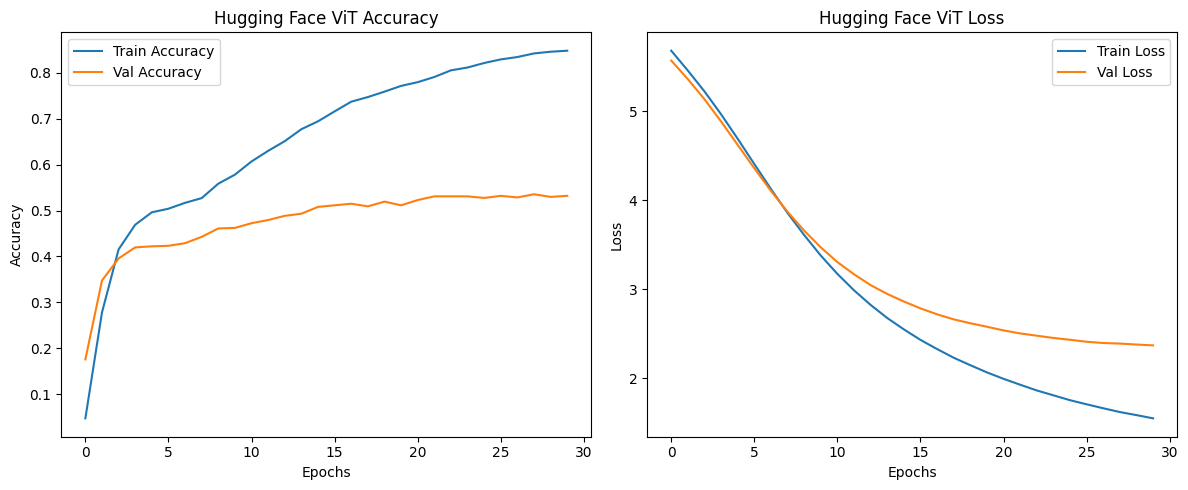

In [7]:
# ============================================================
# DEEP LEARNING PIPELINE (HUGGING FACE ViT END-TO-END)
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from transformers import ViTForImageClassification # IMPORT TỪ HUGGING FACE
import json
import matplotlib.pyplot as plt
import copy
from tqdm import tqdm

print("Initializing PyTorch + Hugging Face Pipeline...")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define paths for all splits
train_dir = './processed_dataset/train'
val_dir = './processed_dataset/val'
test_dir = './processed_dataset/test'

# ==========================================
# 1. Data Augmentation and Normalization
# ==========================================
print("Loading HuggingFace ViT Transforms...")
# ViT in21k sử dụng Normalize [0.5, 0.5, 0.5] thay vì [0.485, 0.456, 0.406]
hf_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Ép chuẩn kích thước 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_ds = datasets.ImageFolder(train_dir, transform=hf_transforms)
val_ds = datasets.ImageFolder(val_dir, transform=hf_transforms)
test_ds = datasets.ImageFolder(test_dir, transform=hf_transforms)

# ==========================================
# 2. Load DataLoaders
# ==========================================
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# Load class counts
with open('label_map.json', 'r') as f:
    label_map = json.load(f)
NUM_CLASSES = len(label_map)

# ==========================================
# 3. Build Fine-Tuned Model (Hugging Face - MỞ KHÓA LAYER)
# ==========================================
print("Loading Hugging Face ViT (google/vit-base-patch16-224-in21k)...")
dl_model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224-in21k',
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)

# 1. Đầu tiên, đóng băng toàn bộ
for param in dl_model.vit.parameters():
    param.requires_grad = False

# 2. MỞ KHÓA (Unfreeze) 2 block Transformer cuối cùng (Layer 10 và 11)
for param in dl_model.vit.encoder.layer[-2:].parameters():
    param.requires_grad = True

# 3. Mở khóa LayerNorm cuối cùng trước khi vào Classifier
for param in dl_model.vit.layernorm.parameters():
    param.requires_grad = True

dl_model = dl_model.to(device)

# ==========================================
# 4. Optimizer, Loss Function, and Scheduler
# ==========================================
criterion = nn.CrossEntropyLoss()

# Dùng Learning Rate RẤT NHỎ (1e-4) vì chúng ta đang đụng vào các layer cốt lõi của in21k
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, dl_model.parameters()),
    lr=1e-4,
    weight_decay=1e-2
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6)

# ==========================================
# 5. Training Loop with Early Stopping
# ==========================================
num_epochs = 30
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_wts = copy.deepcopy(dl_model.state_dict())

history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

print("\n🚀 Starting Hugging Face ViT Training Phase...")
for epoch in range(num_epochs):
    dl_model.train()
    running_loss, running_corrects, total = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        # ĐIỂM KHÁC BIỆT: Phải gọi .logits với mô hình Hugging Face
        outputs = dl_model(inputs).logits

        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total += inputs.size(0)

    train_loss = running_loss / total
    train_acc = running_corrects.double() / total

    # Validation Phase
    dl_model.eval()
    val_loss, val_corrects, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # ĐIỂM KHÁC BIỆT: Phải gọi .logits
            outputs = dl_model(inputs).logits

            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)
            val_total += inputs.size(0)

    val_loss = val_loss / val_total
    val_acc = val_corrects.double() / val_total

    # Step the learning rate scheduler
    scheduler.step(val_loss)

    # Save history
    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc.item())
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc.item())

    print(f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # Early Stopping Logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(dl_model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("\n🛑 Early stopping triggered!")
            break

# Load the best model weights
dl_model.load_state_dict(best_model_wts)

# ==========================================
# 6. Evaluate & Visualize
# ==========================================
print("\n📊 Evaluating Hugging Face Model on Test Set...")
dl_model.eval()
test_corrects, test_total = 0, 0
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = dl_model(inputs).logits
        _, preds = torch.max(outputs, 1)
        test_corrects += torch.sum(preds == labels.data)
        test_total += inputs.size(0)

test_acc = test_corrects.double() / test_total
print(f"\n🏆 Final HF ViT Test Accuracy: {test_acc:.4f}")

# Plot Training History
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Val Accuracy')
plt.title('Hugging Face ViT Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Hugging Face ViT Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig("hf_vit_training_history.png", dpi=150)
plt.show()